# Experimentos con XGBoost — AI4I 2020

En este notebook se desarrollarán experimentos con XGBoost para la predicción de fallas de máquinas utilizando el dataset AI4I 2020.

Los resultados serán comparados con el modelo baseline de regresión logística desarrollado previamente, manteniendo las mismas variables predictoras y la misma estrategia de división de los datos.

Debido al desbalance de la variable objetivo, se prestará especial atención a las métricas precision, recall, F1-score y PR-AUC.

In [1]:
!pip install -q ucimlrepo xgboost

In [2]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga y preparación del dataset

Se carga el dataset AI4I 2020 desde UCI Machine Learning Repository.

Para garantizar una comparación consistente con el modelo baseline, se utilizan las mismas seis variables predictoras y la misma variable objetivo.

In [3]:
dataset = fetch_ucirepo(id=601)

df = dataset.data.original

features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

target = "Machine failure"

X = df[features].copy()
y = df[target].copy()

print("Dataset:", df.shape)
print("X:", X.shape)
print("y:", y.shape)

X.head()

Dataset: (10000, 14)
X: (10000, 6)
y: (10000,)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 3. División de los datos

Se utiliza la misma estrategia de división empleada en el modelo baseline: 80 % de los registros para entrenamiento y 20 % para prueba.

La división es estratificada para conservar la proporción de fallas y se utiliza `random_state=42` para garantizar reproducibilidad y permitir una comparación consistente entre los modelos.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribución prueba:")
print(y_test.value_counts(normalize=True).round(4))

Entrenamiento: (8000, 6)
Prueba: (2000, 6)

Distribución entrenamiento:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Distribución prueba:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


## 4. Preprocesamiento para XGBoost

La variable `Type` es categórica, por lo que se transforma mediante One-Hot Encoding antes de ser utilizada por XGBoost.

Las variables numéricas se mantienen sin transformación adicional. El preprocesamiento se integrará con el modelo mediante un pipeline para mantener un flujo reproducible.

In [5]:
categorical_features = ["Type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Type'])])

## 5. Modelo XGBoost inicial

Se construye un primer modelo XGBoost utilizando una configuración inicial sin aplicar todavía técnicas específicas para tratar el desbalance de clases.

Este modelo permitirá establecer el desempeño inicial de XGBoost antes de realizar ajustes relacionados con el desbalance o la optimización de hiperparámetros.

In [6]:
xgb_initial = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_initial)
    ]
)

xgb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorica...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 6. Entrenamiento del modelo inicial

El pipeline de XGBoost se entrena utilizando los 8 000 registros correspondientes al conjunto de entrenamiento.

En esta primera ejecución se mantienen los parámetros iniciales del clasificador y no se aplica todavía ningún ajuste específico para el desbalance de clases.

In [7]:
xgb_pipeline.fit(X_train, y_train)

print("Modelo XGBoost entrenado correctamente.")

Modelo XGBoost entrenado correctamente.


## 7. Evaluación del modelo XGBoost inicial

Se evalúa el modelo sobre el conjunto de prueba utilizando las mismas métricas empleadas en el modelo baseline: accuracy, precision, recall, F1-score y PR-AUC.

Debido al desbalance de clases, se dará mayor importancia a recall, F1-score y PR-AUC que a accuracy.

In [8]:
# Predicciones de clase
y_pred = xgb_pipeline.predict(X_test)

# Probabilidad de la clase positiva (falla)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_prob)

print("XGBoost inicial")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

XGBoost inicial
Accuracy:  0.9880
Precision: 0.9074
Recall:    0.7206
F1-score:  0.8033
PR-AUC:    0.8101


## 8. Matriz de confusión

Se analiza la matriz de confusión del modelo XGBoost inicial para observar la cantidad de verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.

En un escenario de mantenimiento predictivo, los falsos negativos son especialmente relevantes, ya que representan máquinas que presentan una falla real pero que el modelo clasifica como funcionamiento normal.

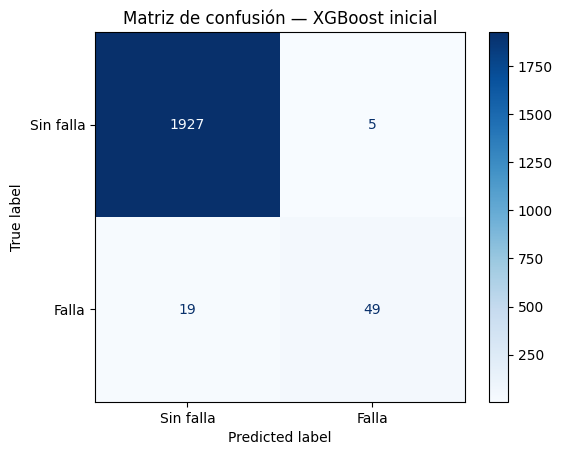

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sin falla", "Falla"],
    cmap="Blues"
)

plt.title("Matriz de confusión — XGBoost inicial")
plt.show()

## 9. Tratamiento del desbalance de clases

La variable objetivo presenta un fuerte desbalance, ya que las fallas representan aproximadamente el 3.4 % de los registros.

Para evaluar el efecto de este desbalance sobre XGBoost, se utilizará el parámetro `scale_pos_weight`, calculado a partir de la proporción entre observaciones negativas y positivas del conjunto de entrenamiento.

El cálculo se realiza exclusivamente con los datos de entrenamiento para evitar utilizar información del conjunto de prueba durante la construcción del modelo.

In [10]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Registros sin falla:", negative_count)
print("Registros con falla:", positive_count)
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Registros sin falla: 7729
Registros con falla: 271
scale_pos_weight: 28.5203


## 10. XGBoost con tratamiento del desbalance

Se entrena un segundo modelo XGBoost incorporando `scale_pos_weight` para dar mayor importancia a la clase minoritaria durante el entrenamiento.

El valor utilizado se calculó exclusivamente a partir del conjunto de entrenamiento, obteniendo una relación aproximada de 28.52 observaciones sin falla por cada observación con falla.

El objetivo de este experimento es analizar si el tratamiento explícito del desbalance permite detectar una mayor proporción de fallas y cómo afecta al resto de métricas de clasificación.

In [11]:
xgb_balanced = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_balanced)
    ]
)

xgb_balanced_pipeline.fit(X_train, y_train)

print("XGBoost con tratamiento del desbalance entrenado correctamente.")

XGBoost con tratamiento del desbalance entrenado correctamente.


## 11. Evaluación de XGBoost con tratamiento del desbalance

El segundo modelo se evalúa sobre el mismo conjunto de prueba utilizado en los experimentos anteriores.

Se calculan accuracy, precision, recall, F1-score y PR-AUC para analizar el efecto de `scale_pos_weight` y compararlo posteriormente con XGBoost inicial y con el modelo baseline de regresión logística.

In [12]:
# Predicciones de clase
y_pred_balanced = xgb_balanced_pipeline.predict(X_test)

# Probabilidad de la clase positiva
y_prob_balanced = xgb_balanced_pipeline.predict_proba(X_test)[:, 1]

# Métricas
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
pr_auc_balanced = average_precision_score(y_test, y_prob_balanced)

print("XGBoost con tratamiento del desbalance")
print(f"Accuracy:  {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall:    {recall_balanced:.4f}")
print(f"F1-score:  {f1_balanced:.4f}")
print(f"PR-AUC:    {pr_auc_balanced:.4f}")

XGBoost con tratamiento del desbalance
Accuracy:  0.9810
Precision: 0.7083
Recall:    0.7500
F1-score:  0.7286
PR-AUC:    0.8366


## 12. Matriz de confusión del modelo con tratamiento del desbalance

Se analiza la matriz de confusión del modelo XGBoost entrenado con `scale_pos_weight` para observar cómo el tratamiento del desbalance modifica los falsos negativos y falsos positivos respecto al modelo XGBoost inicial.

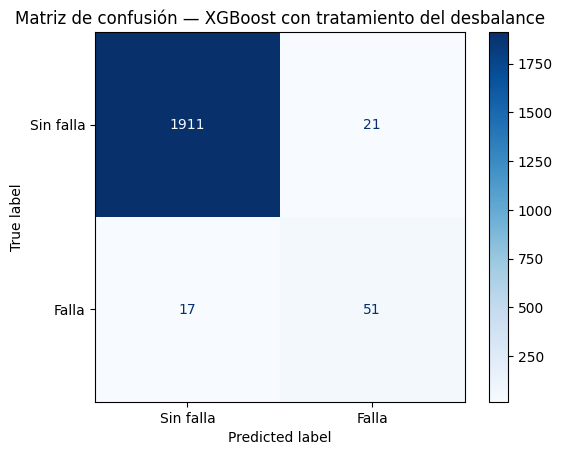

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    display_labels=["Sin falla", "Falla"],
    cmap="Blues"
)

plt.title("Matriz de confusión — XGBoost con tratamiento del desbalance")
plt.show()

## 13. Comparación de los modelos

Se comparan los resultados obtenidos por el modelo baseline de regresión logística, XGBoost inicial y XGBoost con tratamiento del desbalance.

Esta comparación permite analizar el efecto del algoritmo y del tratamiento de la clase minoritaria sobre las diferentes métricas de clasificación.

In [14]:
results = pd.DataFrame({
    "Modelo": [
        "Regresión logística",
        "XGBoost inicial",
        "XGBoost balanceado"
    ],
    "Accuracy": [
        0.9685,
        accuracy,
        accuracy_balanced
    ],
    "Precision": [
        0.6667,
        precision,
        precision_balanced
    ],
    "Recall": [
        0.1471,
        recall,
        recall_balanced
    ],
    "F1-score": [
        0.2410,
        f1,
        f1_balanced
    ],
    "PR-AUC": [
        0.4335,
        pr_auc,
        pr_auc_balanced
    ]
})

results.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,PR-AUC
0,Regresión logística,0.9685,0.6667,0.1471,0.2410,0.4335
1,XGBoost inicial,0.9880,0.9074,0.7206,0.8033,0.8101
2,XGBoost balanceado,0.9810,0.7083,0.7500,0.7286,0.8366


## 14. Creación del conjunto de validación

Para realizar la selección de hiperparámetros sin utilizar el conjunto de prueba como referencia durante el ajuste del modelo, el conjunto de entrenamiento se divide nuevamente en entrenamiento interno y validación.

Se conserva el conjunto de prueba original de 2 000 registros para la evaluación final. La nueva división mantiene la proporción de la variable objetivo mediante estratificación.

In [15]:
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Entrenamiento interno:", X_train_inner.shape)
print("Validación:", X_val.shape)
print("Test final:", X_test.shape)

print("\nDistribución entrenamiento interno:")
print(y_train_inner.value_counts(normalize=True).round(4))

print("\nDistribución validación:")
print(y_val.value_counts(normalize=True).round(4))

Entrenamiento interno: (6400, 6)
Validación: (1600, 6)
Test final: (2000, 6)

Distribución entrenamiento interno:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Distribución validación:
Machine failure
0    0.9662
1    0.0338
Name: proportion, dtype: float64


## 15. Preparación de los datos para la experimentación

El preprocesamiento se ajusta exclusivamente con el conjunto de entrenamiento interno y posteriormente se aplica al conjunto de validación.

De esta manera, las diferentes configuraciones de XGBoost serán evaluadas utilizando exactamente los mismos datos transformados, evitando ajustar el preprocesamiento con información del conjunto de validación.

In [16]:
X_train_inner_processed = preprocessor.fit_transform(X_train_inner)
X_val_processed = preprocessor.transform(X_val)

print("Train procesado:", X_train_inner_processed.shape)
print("Validación procesada:", X_val_processed.shape)

Train procesado: (6400, 8)
Validación procesada: (1600, 8)


## 16. Experimentación con hiperparámetros de XGBoost

Se evalúan diferentes configuraciones de XGBoost sobre el conjunto de validación con el objetivo de analizar el efecto de algunos de sus principales hiperparámetros.

Las configuraciones modifican la cantidad y profundidad de los árboles, la tasa de aprendizaje y las proporciones de observaciones y variables utilizadas durante el entrenamiento.

La selección se realiza utilizando únicamente el conjunto de validación, manteniendo reservado el conjunto de prueba para la evaluación final.

In [17]:
configurations = [
    {
        "name": "config_1",
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.10,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "name": "config_2",
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "config_3",
        "n_estimators": 200,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "config_4",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

experiment_results = []

for config in configurations:

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        random_state=42
    )

    model.fit(X_train_inner_processed, y_train_inner)

    y_val_pred = model.predict(X_val_processed)
    y_val_prob = model.predict_proba(X_val_processed)[:, 1]

    experiment_results.append({
        "Configuración": config["name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1-score": f1_score(y_val, y_val_pred),
        "PR-AUC": average_precision_score(y_val, y_val_prob)
    })

experiments_df = pd.DataFrame(experiment_results)

experiments_df.round(4)

,Configuración,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,Precision,Recall,F1-score,PR-AUC
0,config_1,100,3,0.10,1.0,1.0,0.8485,0.5185,0.6437,0.7468
1,config_2,200,3,0.05,0.8,0.8,0.8889,0.5926,0.7111,0.7807
2,config_3,200,5,0.05,0.8,0.8,0.8684,0.6111,0.7174,0.7749
3,config_4,300,4,0.03,0.8,0.8,0.8462,0.6111,0.7097,0.7753


## 17. Evaluación del balanceo en las configuraciones seleccionadas

A partir de los experimentos anteriores se seleccionan las configuraciones 2 y 3 para analizar el efecto del tratamiento del desbalance.

La configuración 2 presentó el mayor PR-AUC y precision, mientras que la configuración 3 obtuvo el mayor F1-score y un recall superior.

El valor de `scale_pos_weight` se recalcula utilizando exclusivamente el conjunto de entrenamiento interno para mantener la separación entre entrenamiento y validación.

In [18]:
negative_inner = (y_train_inner == 0).sum()
positive_inner = (y_train_inner == 1).sum()

scale_pos_weight_inner = negative_inner / positive_inner

print("Sin falla:", negative_inner)
print("Con falla:", positive_inner)
print(f"scale_pos_weight interno: {scale_pos_weight_inner:.4f}")

Sin falla: 6183
Con falla: 217
scale_pos_weight interno: 28.4931


In [19]:
balanced_configurations = [
    {
        "name": "config_2_balanced",
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "config_3_balanced",
        "n_estimators": 200,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

balanced_results = []

for config in balanced_configurations:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        scale_pos_weight=scale_pos_weight_inner,
        random_state=42
    )

    model.fit(X_train_inner_processed, y_train_inner)

    y_val_pred = model.predict(X_val_processed)
    y_val_prob = model.predict_proba(X_val_processed)[:, 1]

    balanced_results.append({
        "Configuración": config["name"],
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1-score": f1_score(y_val, y_val_pred),
        "PR-AUC": average_precision_score(y_val, y_val_prob)
    })

balanced_experiments_df = pd.DataFrame(balanced_results)

balanced_experiments_df.round(4)

,Configuración,Precision,Recall,F1-score,PR-AUC
0,config_2_balanced,0.2805,0.8519,0.4220,0.7187
1,config_3_balanced,0.5526,0.7778,0.6462,0.7442


## 18. Experimentación con diferentes valores de `scale_pos_weight`

Los resultados anteriores mostraron que utilizar el valor completo de `scale_pos_weight` incrementa considerablemente el recall, pero también reduce la precision y el F1-score.

Por este motivo, se evalúan diferentes valores intermedios de `scale_pos_weight` manteniendo constantes los demás hiperparámetros de la configuración 3.

El objetivo es analizar el equilibrio entre la detección de fallas y la generación de falsos positivos utilizando exclusivamente el conjunto de validación.

In [20]:
weight_values = [
    1,
    2,
    5,
    10,
    15,
    scale_pos_weight_inner
]

weight_results = []

for weight in weight_values:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        random_state=42
    )

    model.fit(X_train_inner_processed, y_train_inner)

    y_val_pred = model.predict(X_val_processed)
    y_val_prob = model.predict_proba(X_val_processed)[:, 1]

    weight_results.append({
        "scale_pos_weight": weight,
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1-score": f1_score(y_val, y_val_pred),
        "PR-AUC": average_precision_score(y_val, y_val_prob)
    })

weight_experiments_df = pd.DataFrame(weight_results)

weight_experiments_df.round(4)

,scale_pos_weight,Precision,Recall,F1-score,PR-AUC
0,1.0000,0.8684,0.6111,0.7174,0.7749
1,2.0000,0.8250,0.6111,0.7021,0.7693
2,5.0000,0.7917,0.7037,0.7451,0.7673
3,10.0000,0.6780,0.7407,0.7080,0.7586
4,15.0000,0.6308,0.7593,0.6891,0.7646
5,28.4931,0.5526,0.7778,0.6462,0.7442


## 19. Selección de la configuración candidata

Los experimentos muestran que incrementar `scale_pos_weight` aumenta progresivamente la capacidad del modelo para detectar fallas, aunque produce una reducción de la precision.

Entre los valores evaluados, `scale_pos_weight = 5` obtuvo el mayor F1-score (0.7451), con una precision de 0.7917 y un recall de 0.7037. Este resultado representa un mejor equilibrio entre la detección de fallas y la generación de falsos positivos bajo el umbral de clasificación predeterminado.

Aunque `scale_pos_weight = 1` obtuvo un PR-AUC ligeramente superior (0.7749 frente a 0.7673), el peso 5 incrementó el recall de 0.6111 a 0.7037 y alcanzó el mayor F1-score de los pesos evaluados.

Por este motivo, se selecciona como configuración candidata `scale_pos_weight = 5`, manteniendo los hiperparámetros de la configuración 3.

In [21]:
selected_params = {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 5
}

selected_params

{'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.05,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'scale_pos_weight': 5}

## 20. Entrenamiento del modelo seleccionado y evaluación final

Una vez seleccionada la configuración candidata mediante el conjunto de validación, el modelo se entrena nuevamente utilizando el conjunto completo de entrenamiento de 8 000 registros.

El preprocesamiento se ajusta exclusivamente con los datos de entrenamiento y posteriormente se aplica al conjunto de prueba. Finalmente, el modelo seleccionado se evalúa sobre los 2 000 registros reservados para la evaluación final.

Esta evaluación permite analizar el desempeño del modelo sobre datos que no fueron utilizados durante la selección de la configuración.

In [22]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["Type"]
        )
    ],
    remainder="passthrough"
)

X_train_final = final_preprocessor.fit_transform(X_train)
X_test_final = final_preprocessor.transform(X_test)

print("Train final:", X_train_final.shape)
print("Test final:", X_test_final.shape)

Train final: (8000, 8)
Test final: (2000, 8)


In [23]:
final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=selected_params["n_estimators"],
    max_depth=selected_params["max_depth"],
    learning_rate=selected_params["learning_rate"],
    subsample=selected_params["subsample"],
    colsample_bytree=selected_params["colsample_bytree"],
    scale_pos_weight=selected_params["scale_pos_weight"],
    random_state=42
)

final_model.fit(X_train_final, y_train)

print("Modelo final entrenado correctamente.")

Modelo final entrenado correctamente.


## 21. Evaluación final del modelo

El modelo seleccionado se evalúa sobre el conjunto de prueba reservado. Para la evaluación se calculan accuracy, precision, recall, F1-score y PR-AUC.

Debido al desbalance de la variable objetivo, el análisis se centra principalmente en precision, recall, F1-score y PR-AUC, mientras que accuracy se presenta como una métrica complementaria.

In [24]:
y_test_pred_final = final_model.predict(X_test_final)
y_test_prob_final = final_model.predict_proba(X_test_final)[:, 1]

final_accuracy = accuracy_score(y_test, y_test_pred_final)
final_precision = precision_score(y_test, y_test_pred_final)
final_recall = recall_score(y_test, y_test_pred_final)
final_f1 = f1_score(y_test, y_test_pred_final)
final_pr_auc = average_precision_score(y_test, y_test_prob_final)

print("XGBoost final")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")
print(f"PR-AUC:    {final_pr_auc:.4f}")

XGBoost final
Accuracy:  0.9830
Precision: 0.7297
Recall:    0.7941
F1-score:  0.7606
PR-AUC:    0.8301


## 22. Matriz de confusión del modelo final

La matriz de confusión permite analizar los aciertos y errores del modelo final sobre el conjunto de prueba.

En particular, permite identificar la cantidad de fallas detectadas correctamente, fallas no detectadas y falsas alarmas generadas por el modelo.

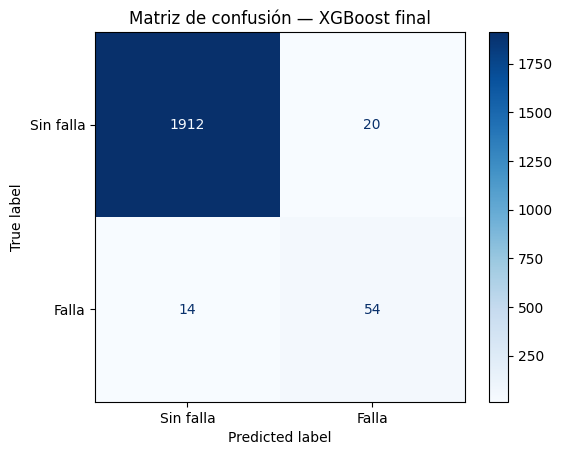

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_final,
    display_labels=["Sin falla", "Falla"],
    cmap="Blues"
)

plt.title("Matriz de confusión — XGBoost final")
plt.show()

## 23. Comparación final de modelos

Finalmente, se comparan los resultados obtenidos por la regresión logística utilizada como baseline, el XGBoost inicial, el XGBoost con tratamiento completo del desbalance y el XGBoost seleccionado mediante los experimentos de validación.

La comparación permite observar la evolución del desempeño del modelo y el efecto de la selección de hiperparámetros y del ajuste de `scale_pos_weight`.

In [27]:
final_comparison = pd.DataFrame({
    "Modelo": [
        "Regresión logística",
        "XGBoost inicial",
        "XGBoost balanceado (28.52)",
        "XGBoost final (peso 5)"
    ],
    "Accuracy": [
        0.9685,
        0.9880,
        0.9810,
        final_accuracy
    ],
    "Precision": [
        0.6667,
        0.9074,
        0.7083,
        final_precision
    ],
    "Recall": [
        0.1471,
        0.7206,
        0.7500,
        final_recall
    ],
    "F1-score": [
        0.2410,
        0.8033,
        0.7286,
        final_f1
    ],
    "PR-AUC": [
        0.4335,
        0.8101,
        0.8366,
        final_pr_auc
    ]
})

final_comparison.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,PR-AUC
0,Regresión logística,0.9685,0.6667,0.1471,0.2410,0.4335
1,XGBoost inicial,0.9880,0.9074,0.7206,0.8033,0.8101
2,XGBoost balanceado (28.52),0.9810,0.7083,0.7500,0.7286,0.8366
3,XGBoost final (peso 5),0.9830,0.7297,0.7941,0.7606,0.8301


## 24. Conclusiones

La regresión logística utilizada como baseline presentó una accuracy elevada (0.9685), pero un recall de solo 0.1471, evidenciando que la accuracy por sí sola no representa adecuadamente el desempeño en este problema debido al desbalance de clases.

El XGBoost inicial mejoró considerablemente la detección de fallas, alcanzando un recall de 0.7206 y un F1-score de 0.8033.

La aplicación del valor completo de `scale_pos_weight` incrementó el recall, pero produjo una reducción considerable de la precision. Los experimentos realizados sobre el conjunto de validación mostraron que un valor intermedio de `scale_pos_weight = 5` ofrecía un equilibrio más adecuado para incrementar la detección de fallas sin penalizar excesivamente las falsas alarmas.

El modelo seleccionado alcanzó en el conjunto de prueba una accuracy de 0.9830, precision de 0.7297, recall de 0.7941, F1-score de 0.7606 y PR-AUC de 0.8301.

La matriz de confusión mostró que el modelo identificó correctamente 54 de las 68 fallas presentes en el conjunto de prueba, mientras que 14 fallas no fueron detectadas y se generaron 20 falsas alarmas.

En conjunto, los experimentos muestran que XGBoost ofrece una mejora sustancial frente al baseline de regresión logística y que el tratamiento del desbalance permite modificar el compromiso entre precision y recall según las necesidades del problema de mantenimiento predictivo.